# PEMS-XGBoost CO — evaluación walk-forward FINAL R1F_STD

**Propósito:** consumir sin cambios la configuración FROZEN producida por
`07_XGBoost_CO_WF_OPT - R1_POC_EFFICIENT.ipynb`, entrenar diez modelos con DEV
2011–2014 y evaluar una sola vez el holdout prospectivo de 2015 (`WF04`).

**Entradas:** protocolo `WF_PROTOCOL_R1`, `BEST_CONFIG`, política final,
manifiesto FROZEN y handoff del notebook OPT. **Salidas:** modelos UBJ,
predicciones, métricas por semilla y ensamble, diagnósticos por decil,
importancia, complejidad, almacenamiento y latencia CPU.

**Estado:** FINAL / STANDARDIZED. No contiene Optuna ni reabre decisiones.
XGBoost es exclusivamente data-driven; no aplica restricciones monotónicas,
física, sintéticos, escalamiento de X ni clipping de predicciones.

**Barrera TEST:** la existencia, el encabezado y el contenido de `gt_2015.csv`
solo se consultan después de autenticar el handoff y congelar diez modelos con
todo DEV.

## Mapa del notebook

| Sección | Finalidad |
|---|---|
| SEC-01 | entorno, rutas y utilidades |
| SEC-02 | autenticación de protocolo y OPT FROZEN |
| SEC-03 | carga exclusiva de DEV 2011–2014 |
| SEC-04 | entrenamiento final de diez semillas |
| SEC-05 | puerta previa y apertura única de 2015 |
| SEC-06 | evaluación `WF04` por semilla y ensamble |
| SEC-07 | diagnósticos, importancia y figuras |
| SEC-08 | complejidad, bytes y latencia CPU |
| SEC-09 | manifiesto, hashes y cierre |

## SEC-01 — Entorno, rutas y utilidades

### C-01.01 / CFG-01 — Bootstrap y configuración operativa

El backend puede ser CPU/CUDA, pero la configuración científica y las diez
semillas se leen exclusivamente de los artefactos FROZEN.


In [1]:
# [C-01.01] Bootstrap, imports y constantes
import importlib.metadata
import importlib.util
import io
import os
import re
import subprocess
import sys
from pathlib import Path

PROJECT_ROOT_PATH = os.environ.get(
    "PEMS_PROJECT_ROOT",
    "/content/drive/MyDrive/Turbine_Emissions_PINN",
)
DEVICE_PREFERENCE = os.environ.get("PEMS_XGB_DEVICE", "AUTO").upper()
if DEVICE_PREFERENCE not in {"AUTO", "CPU", "CUDA"}:
    raise ValueError("DEVICE_PREFERENCE debe ser AUTO, CPU o CUDA")

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "xgboost": "xgboost>=2.0",
    "psutil": "psutil",
}
minimum_versions = {"xgboost": (2, 0)}


def major_minor(version_text: str) -> tuple[int, int]:
    numbers = [int(item) for item in re.findall(r"\d+", version_text)]
    return tuple((numbers + [0, 0])[:2])


missing_packages = []
for module, package in required_packages.items():
    if importlib.util.find_spec(module) is None:
        missing_packages.append(package)
        continue
    minimum = minimum_versions.get(module)
    if minimum is None:
        continue
    try:
        installed = importlib.metadata.version(module)
    except importlib.metadata.PackageNotFoundError:
        missing_packages.append(package)
        continue
    if major_minor(installed) < minimum:
        missing_packages.append(package)

if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

from dataclasses import dataclass
from datetime import datetime, timezone
import hashlib
import json
import platform
import random
import shutil
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import xgboost as xgb
from IPython.display import display
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

VERSION = "XGBOOST_CO_WF_FINAL_R1F_STD"
PROTOCOL_VERSION = "WF_PROTOCOL_R1"
OPT_VERSION = "XGBOOST_CO_WF_OPT_R1_POC_EFFICIENT"
CURRENT_NOTEBOOK_NAME = "07_XGBoost_CO_WF_FINAL - R1F_STD.ipynb"
PROTOCOL_NOTEBOOK_NAME = "00_PEMS_PINN_WF_PROTOCOL - R1.ipynb"
OPT_NOTEBOOK_NAME = "07_XGBoost_CO_WF_OPT - R1_POC_EFFICIENT.ipynb"
FEATURES = [
    "AT", "AP", "AH", "AFDP", "GTEP",
    "TIT", "TAT", "TEY", "CDP",
]
TARGET = "CO"
OTHER_TARGET = "NOX"
DEVELOPMENT_YEARS = [2011, 2012, 2013, 2014]
FINAL_TEST_YEAR = 2015
DEVELOPMENT_FOLD_NAMES = ["WF01", "WF02", "WF03"]
PURE_DATA_DRIVEN = True
RAW_DATA_REL = Path("data") / "raw"
PROTOCOL_REL = Path("models") / "wf" / "work_pinn_wf_protocol"
OPT_REL = Path("models/wf/work_xgboost_co_wf_opt_r1_poc_efficient")
OUTPUT_REL = Path("models/wf/work_xgboost_co_wf_final_r1f_std")
REPRESENTATIVE_SEED = 42
EXPECTED_FINAL_SEEDS = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210]
LATENCY_WARMUP = 50
LATENCY_REPETITIONS = 200
THROUGHPUT_WARMUP = 10
THROUGHPUT_REPETITIONS = 30

### C-01.02 / CHK-01 — Utilidades, rutas y backend

**Control:** raíz canónica explícita, escritura atómica y selección única
del dispositivo. La medición de despliegue se ejecuta en CPU.


In [2]:
# [C-01.02] Utilidades, rutas e inicialización
def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_bytes(payload: bytes) -> str:
    return hashlib.sha256(payload).hexdigest()


def canonical_json_hash(payload: dict) -> str:
    encoded = json.dumps(
        payload,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
    return sha256_bytes(encoded)


def atomic_text(path: Path, text: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w",
        encoding="utf-8",
        dir=path.parent,
        delete=False,
    ) as handle:
        handle.write(text)
        temporary = Path(handle.name)
    temporary.replace(path)


def atomic_json(path: Path, payload: dict) -> None:
    atomic_text(path, json.dumps(payload, ensure_ascii=False, indent=2))


def atomic_csv(path: Path, frame: pd.DataFrame) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w",
        encoding="utf-8",
        newline="",
        dir=path.parent,
        delete=False,
    ) as handle:
        frame.to_csv(handle, index=False)
        temporary = Path(handle.name)
    temporary.replace(path)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


@dataclass(frozen=True)
class FinalPaths:
    work: Path
    audit: Path
    configs: Path
    figures_test: Path
    figures_summary: Path
    models: Path
    reports: Path
    tables: Path


def validate_project_root(path_value: str) -> Path:
    """Valida solo protocolo y OPT; no consulta el holdout."""
    root = Path(path_value).expanduser()
    if not root.is_absolute():
        raise ValueError("PROJECT_ROOT_PATH debe ser una ruta absoluta")
    root = root.resolve()
    required = [root / PROTOCOL_REL, root / OPT_REL]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Entradas FROZEN ausentes: {missing}")
    return root


def create_paths(root: Path) -> FinalPaths:
    work = root / OUTPUT_REL
    paths = FinalPaths(
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        figures_test=work / "figures" / "test",
        figures_summary=work / "figures" / "summary",
        models=work / "models",
        reports=work / "reports",
        tables=work / "tables",
    )
    for path in paths.__dict__.values():
        Path(path).mkdir(parents=True, exist_ok=True)
    return paths


def select_device() -> str:
    if DEVICE_PREFERENCE == "CPU":
        return "cpu"
    wants_cuda = DEVICE_PREFERENCE == "CUDA" or (
        DEVICE_PREFERENCE == "AUTO" and shutil.which("nvidia-smi") is not None
    )
    if not wants_cuda:
        return "cpu"
    try:
        probe = xgb.XGBRegressor(
            n_estimators=2,
            tree_method="hist",
            device="cuda",
            verbosity=0,
        )
        probe.fit(
            np.arange(64, dtype=np.float32).reshape(32, 2),
            np.arange(32, dtype=np.float32),
            verbose=False,
        )
        return "cuda"
    except (xgb.core.XGBoostError, RuntimeError) as exc:
        if DEVICE_PREFERENCE == "CUDA":
            raise RuntimeError("Preflight CUDA falló") from exc
        return "cpu"


PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
PATHS = create_paths(PROJECT_ROOT)
DEVICE = select_device()
XGB_N_JOBS = 1 if DEVICE == "cuda" else max(
    1,
    min(8, psutil.cpu_count(logical=False) or 1),
)
if "TEST_ACCESS_COUNT" not in globals():
    TEST_ACCESS_COUNT = 0
if "_TEST_HAS_BEEN_OPENED" not in globals():
    _TEST_HAS_BEEN_OPENED = False
ENVIRONMENT = {
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "device_training": DEVICE,
    "xgb_n_jobs": XGB_N_JOBS,
    "parallelism": "XGBoost internal; final seeds trained serially",
    "python": sys.version,
    "platform": platform.platform(),
    "cpu_physical": psutil.cpu_count(logical=False),
    "cpu_logical": psutil.cpu_count(logical=True),
    "packages": {
        name: importlib.metadata.version(name)
        for name in ["numpy", "pandas", "scikit-learn", "xgboost"]
    },
}
atomic_json(PATHS.audit / "ENVIRONMENT_XGBOOST_CO_WF_FINAL_R1F_STD.json", ENVIRONMENT)
print({"CHK-01": "PASS", "device": DEVICE, "salida": str(PATHS.work)})

{'CHK-01': 'PASS', 'device': 'cuda', 'salida': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\wf\\work_xgboost_co_wf_final_r1f_std'}


## SEC-02 — Autenticación de protocolo y OPT FROZEN

### C-02.01 / ALG-01 / CHK-02 — Verificación integral antes de 2015

**Lógica humana:**
1. autenticar manifests y tablas del protocolo;
2. autenticar `BEST_CONFIG`, política, manifiesto y handoff del OPT;
3. reconciliar versiones, nombres, hashes, folds y configuración;
4. validar únicamente los cuatro CSV DEV;
5. conservar `gt_2015.csv` completamente sin consultar.

In [3]:
# [C-02.01] Verificación integral de entradas FROZEN
def verify_frozen_inputs(root: Path) -> dict:
    """Autentica protocolo y OPT antes de consultar cualquier dato de 2015."""
    protocol_base = root / PROTOCOL_REL
    protocol_paths = {
        "protocol": protocol_base / "manifests" / "WF_PROTOCOL_MANIFEST.json",
        "folds": protocol_base / "manifests" / "WF_FOLDS_MANIFEST.json",
        "consumers": protocol_base / "manifests" / "WF_CONSUMER_CONTRACT.json",
        "general": (
            protocol_base
            / "manifests"
            / "MANIFIESTO_ARTEFACTOS_WF_PROTOCOL.json"
        ),
        "assignment": (
            protocol_base / "tables" / "WF_DEVELOPMENT_ROW_ASSIGNMENT.csv"
        ),
        "fold_summary": protocol_base / "tables" / "WF_FOLDS_SUMMARY.csv",
    }
    opt_base = root / OPT_REL
    opt_paths = {
        "best_config": opt_base / "configs" / "BEST_CONFIG_XGBOOST_CO_WF_R1.json",
        "policy": (
            opt_base
            / "configs"
            / "FINAL_TRAINING_POLICY_XGBOOST_CO_WF_R1.json"
        ),
        "frozen": (
            opt_base
            / "configs"
            / "FROZEN_CONFIG_MANIFEST_XGBOOST_CO_WF_R1.json"
        ),
        "handoff": (
            opt_base / "reports" / "HANDOFF_XGBOOST_CO_WF_R1_TO_FINAL.json"
        ),
    }
    required = {**protocol_paths, **opt_paths}
    missing = [str(path) for path in required.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Entradas FROZEN ausentes: {missing}")

    protocol = json.loads(protocol_paths["protocol"].read_text(encoding="utf-8"))
    folds = json.loads(protocol_paths["folds"].read_text(encoding="utf-8"))
    consumers = json.loads(protocol_paths["consumers"].read_text(encoding="utf-8"))
    general = json.loads(protocol_paths["general"].read_text(encoding="utf-8"))
    for name, manifest in {
        "protocol": protocol,
        "folds": folds,
        "consumers": consumers,
        "general": general,
    }.items():
        if manifest.get("status") != "FROZEN":
            raise RuntimeError(f"Protocolo {name} no FROZEN")
        if manifest.get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"Versión inesperada en {name}")

    indexed = {
        str(item["path"]).replace("\\", "/"): item["sha256"]
        for item in general.get("artifacts", [])
    }
    canonical = {
        "manifests/WF_PROTOCOL_MANIFEST.json": protocol_paths["protocol"],
        "manifests/WF_FOLDS_MANIFEST.json": protocol_paths["folds"],
        "manifests/WF_CONSUMER_CONTRACT.json": protocol_paths["consumers"],
        "tables/WF_DEVELOPMENT_ROW_ASSIGNMENT.csv": protocol_paths["assignment"],
        "tables/WF_FOLDS_SUMMARY.csv": protocol_paths["fold_summary"],
    }
    for relative, path in canonical.items():
        if indexed.get(relative) != sha256_file(path):
            raise RuntimeError(f"Artefacto de protocolo no autenticado: {relative}")

    assignment = pd.read_csv(protocol_paths["assignment"])
    assignment_hash = sha256_file(protocol_paths["assignment"])
    fold_hash = sha256_file(protocol_paths["fold_summary"])
    if assignment_hash != protocol.get("row_assignment_sha256"):
        raise RuntimeError("Hash assignment inconsistente")
    if assignment_hash != folds.get("row_assignment_sha256"):
        raise RuntimeError("Hash assignment distinto en folds")
    if fold_hash != protocol.get("fold_summary_sha256"):
        raise RuntimeError("Hash fold summary inconsistente")
    if fold_hash != folds.get("fold_summary_sha256"):
        raise RuntimeError("Hash fold summary distinto en folds")
    if sorted(assignment.year.unique().tolist()) != DEVELOPMENT_YEARS:
        raise RuntimeError("Assignment contiene años no autorizados")
    if FINAL_TEST_YEAR in assignment.year.unique():
        raise RuntimeError("Assignment materializa 2015")

    common = consumers.get("common_contract", {})
    if common.get("scenario") != "ANNUAL_EXPANDING_WALK_FORWARD":
        raise RuntimeError("Escenario de protocolo incompatible")
    if common.get("development_folds") != DEVELOPMENT_FOLD_NAMES:
        raise RuntimeError("Folds DEV incompatibles")
    if not common.get("final_may_open_2015_after_frozen_handoff"):
        raise RuntimeError("El protocolo no autoriza WF04 tras handoff")
    if folds.get("final_fold") != "WF04":
        raise RuntimeError("WF04 no está reservado para FINAL")

    best_config = json.loads(opt_paths["best_config"].read_text(encoding="utf-8"))
    policy = json.loads(opt_paths["policy"].read_text(encoding="utf-8"))
    frozen = json.loads(opt_paths["frozen"].read_text(encoding="utf-8"))
    handoff = json.loads(opt_paths["handoff"].read_text(encoding="utf-8"))
    if any(item.get("status") != "FROZEN" for item in [best_config, policy, frozen]):
        raise RuntimeError("OPT no está completamente FROZEN")
    if handoff.get("status") != "READY":
        raise RuntimeError("Handoff OPT no está READY")
    if any(
        item.get("version") != OPT_VERSION
        for item in [best_config, policy, frozen, handoff]
    ):
        raise RuntimeError("Versión OPT inconsistente")
    if any(
        item.get("target") != TARGET
        for item in [best_config, policy, frozen, handoff]
    ):
        raise RuntimeError("Target inconsistente en artefactos OPT")
    if frozen.get("producer_notebook") != OPT_NOTEBOOK_NAME:
        raise RuntimeError("Productor OPT inesperado")
    if frozen.get("authorized_consumer") != CURRENT_NOTEBOOK_NAME:
        raise RuntimeError("Este notebook no es el consumidor autorizado")
    if frozen.get("campaign_complete") is not True:
        raise RuntimeError("La campaña OPT no quedó completa")
    if frozen.get("fold_execution_policy") != (
        "ALL_THREE_WF_FOLDS_FOR_RANKABLE_EVIDENCE"
    ):
        raise RuntimeError("Política de folds OPT incompatible")
    if frozen.get("partial_temporal_screening") is not False:
        raise RuntimeError("OPT declara screening temporal parcial")
    fingerprint_payload = frozen.get("study_fingerprint_payload")
    fingerprint_sha = frozen.get("study_fingerprint_sha256")
    if not isinstance(fingerprint_payload, dict):
        raise RuntimeError("FROZEN no contiene el payload del fingerprint")
    if canonical_json_hash(fingerprint_payload) != fingerprint_sha:
        raise RuntimeError("Fingerprint FROZEN inválido")
    if handoff.get("study_fingerprint_sha256") != fingerprint_sha:
        raise RuntimeError("Handoff y FROZEN difieren en fingerprint")
    expected_ranking_rule = (
        "worst_fold_median_R2_desc_then_R2_q10_desc_then_R2_median_desc_"
        "R2_mean_desc_RMSE_MAE_bias_std_bytes_asc"
    )
    if frozen.get("confirmation_ranking_rule") != expected_ranking_rule:
        raise RuntimeError("Regla de confirmación FROZEN incompatible")
    if best_config.get("ranking_rule") != expected_ranking_rule:
        raise RuntimeError("BEST_CONFIG no congela la regla robusta")
    if any(
        value is not False
        for value in [
            best_config.get("test_opened"),
            best_config.get("test_content_hashed"),
            policy.get("test_used"),
            frozen.get("test_opened"),
            frozen.get("test_content_hashed"),
            handoff.get("test_opened"),
            handoff.get("test_content_hashed"),
        ]
    ):
        raise RuntimeError("OPT declara acceso indebido a 2015")
    if handoff.get("source_notebook") != OPT_NOTEBOOK_NAME:
        raise RuntimeError("Fuente del handoff inesperada")
    if handoff.get("destination_notebook") != CURRENT_NOTEBOOK_NAME:
        raise RuntimeError("Destino del handoff inesperado")

    expected_frozen_rel = str(opt_paths["frozen"].relative_to(root)).replace(
        "\\", "/"
    )
    if handoff.get("frozen_manifest_path") != expected_frozen_rel:
        raise RuntimeError("Ruta del manifiesto FROZEN no autenticada")
    if handoff.get("frozen_manifest_sha256") != sha256_file(opt_paths["frozen"]):
        raise RuntimeError("Hash del manifiesto FROZEN inconsistente")
    if frozen.get("best_config_sha256") != sha256_file(opt_paths["best_config"]):
        raise RuntimeError("Hash BEST_CONFIG inconsistente")
    if frozen.get("training_policy_sha256") != sha256_file(opt_paths["policy"]):
        raise RuntimeError("Hash training policy inconsistente")
    config_hashes = {
        best_config.get("config_hash"),
        policy.get("config_hash"),
        frozen.get("config_hash"),
        handoff.get("config_hash"),
    }
    if len(config_hashes) != 1 or None in config_hashes:
        raise RuntimeError("Config hash difiere entre artefactos")
    hash_payload = dict(best_config)
    declared_config_hash = hash_payload.pop("config_hash")
    if canonical_json_hash(hash_payload) != declared_config_hash:
        raise RuntimeError("Contenido BEST_CONFIG no coincide con config_hash")

    pure = best_config.get("pure_data_driven_contract", {})
    if frozen.get("pure_data_driven_contract") != pure:
        raise RuntimeError("Contrato data-driven difiere en el manifiesto")
    if not pure.get("pure_data_driven"):
        raise RuntimeError("BEST_CONFIG no declara modelo data-driven")
    if pure.get("monotone_constraints") is not None:
        raise RuntimeError("BEST_CONFIG contiene monotonía")
    if best_config.get("features") != FEATURES:
        raise RuntimeError("BEST_CONFIG no utiliza RAW_9 canónico")
    if best_config.get("target_transform") not in {"identity", "log1p"}:
        raise RuntimeError("Transformación CO no autorizada")
    if best_config.get("development_folds") != DEVELOPMENT_FOLD_NAMES:
        raise RuntimeError("BEST_CONFIG no referencia WF01–WF03")
    if assignment_hash != frozen.get("row_assignment_sha256"):
        raise RuntimeError("OPT y protocolo difieren en assignment")
    if fold_hash != frozen.get("fold_summary_sha256"):
        raise RuntimeError("OPT y protocolo difieren en fold summary")
    if frozen.get("protocol_general_manifest_sha256") != sha256_file(
        protocol_paths["general"]
    ):
        raise RuntimeError("OPT y FINAL no autentican el mismo protocolo")

    dev_sources = {}
    declared_dev = {
        int(item["year"]): item
        for item in protocol.get("development_data_hashes", [])
    }
    for year in DEVELOPMENT_YEARS:
        record = declared_dev.get(year)
        if record is None:
            raise RuntimeError(f"Falta fuente DEV {year}")
        relative = Path(str(record["path"]).replace("\\", "/"))
        expected = Path("data") / "raw" / f"gt_{year}.csv"
        if relative != expected or relative.is_absolute():
            raise RuntimeError(f"Ruta DEV no canónica para {year}")
        path = root / relative
        if not path.is_file() or sha256_file(path) != record.get("sha256"):
            raise RuntimeError(f"Hash DEV distinto en {year}")
        dev_sources[year] = path

    expected_rows = protocol.get("expected_rows_by_year", {})
    expected_test_rows = int(
        expected_rows.get(str(FINAL_TEST_YEAR), expected_rows.get(FINAL_TEST_YEAR, 0))
    )
    if expected_test_rows <= 0:
        raise RuntimeError("El protocolo no declara el conteo de 2015")

    audit = pd.DataFrame(
        [
            {
                "artifact": name,
                "path": str(path.relative_to(root)).replace("\\", "/"),
                "sha256": sha256_file(path),
                "status": "PASS",
            }
            for name, path in required.items()
        ]
    )
    atomic_csv(PATHS.audit / "FROZEN_INPUT_AUDIT_XGBOOST_CO_WF_R1F.csv", audit)
    return {
        "assignment": assignment,
        "assignment_hash": assignment_hash,
        "fold_hash": fold_hash,
        "protocol_general_sha256": sha256_file(protocol_paths["general"]),
        "best_config": best_config,
        "policy": policy,
        "frozen": frozen,
        "handoff": handoff,
        "paths": opt_paths,
        "dev_sources": dev_sources,
        "expected_test_rows": expected_test_rows,
    }


FROZEN = verify_frozen_inputs(PROJECT_ROOT)
ASSIGNMENT = FROZEN["assignment"]
BEST_CONFIG = FROZEN["best_config"]
FINAL_TRAINING_POLICY = FROZEN["policy"]
FINAL_SEEDS = [int(seed) for seed in FINAL_TRAINING_POLICY["final_seeds"]]
FINAL_N_ESTIMATORS = int(FINAL_TRAINING_POLICY["final_n_estimators"])
ENSEMBLE_RULE = FINAL_TRAINING_POLICY["ensemble_rule"]
if FINAL_SEEDS != EXPECTED_FINAL_SEEDS:
    raise RuntimeError("La política no contiene las diez semillas predeclaradas")
if ENSEMBLE_RULE != "arithmetic_mean_all_predeclared_seeds":
    raise RuntimeError("Regla de ensamble inesperada")
print(
    {
        "CHK-02": "PASS",
        "config_hash": BEST_CONFIG["config_hash"],
        "final_n_estimators": FINAL_N_ESTIMATORS,
        "seeds": len(FINAL_SEEDS),
        "2015_consultado": False,
    }
)

{'CHK-02': 'PASS', 'config_hash': '54da4c07c37bc77d482bdba3f32fd36870adc3eb31e2795748e35698894442a7', 'final_n_estimators': 144, 'seeds': 10, '2015_consultado': False}


## SEC-03 — Carga exclusiva de DEV

### C-03.01 / CHK-03 — Materialización de 2011–2014

Solo se leen las nueve entradas y CO. NOX no se materializa y 2015 permanece
sin existencia, encabezado, tamaño ni hash consultados.

In [4]:
# [C-03.01] Materialización controlada de DEV
def load_dev_authorized(
    assignment: pd.DataFrame,
    data_sources: dict[int, Path],
) -> pd.DataFrame:
    """Carga solo 2011–2014 y únicamente FEATURES + CO."""
    frames = []
    role_columns = [f"{name}_role" for name in DEVELOPMENT_FOLD_NAMES]
    for year in DEVELOPMENT_YEARS:
        metadata = assignment.loc[assignment.year.eq(year)].sort_values(
            "row_in_year"
        )
        raw_path = data_sources[year]
        header = pd.read_csv(raw_path, nrows=0).columns.tolist()
        if not set(FEATURES + [TARGET, OTHER_TARGET]).issubset(header):
            raise ValueError(f"Columnas faltantes en {raw_path.name}")
        values = pd.read_csv(raw_path, usecols=FEATURES + [TARGET])[
            FEATURES + [TARGET]
        ]
        if len(values) != len(metadata):
            raise RuntimeError(f"Carga DEV falló en {year}")
        identity_columns = [
            "global_row_id",
            "year",
            "row_in_year",
            "global_position",
            *role_columns,
        ]
        frames.append(
            pd.concat(
                [
                    metadata[identity_columns].reset_index(drop=True),
                    values.reset_index(drop=True),
                ],
                axis=1,
            )
        )
    data = pd.concat(frames, ignore_index=True)
    if sorted(data.year.unique().tolist()) != DEVELOPMENT_YEARS:
        raise RuntimeError("La carga DEV mezcló años")
    if data.global_row_id.duplicated().any():
        raise RuntimeError("IDs duplicados en DEV")
    if not np.isfinite(data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("NaN/Inf en DEV")
    return data


DEV_DATA = load_dev_authorized(ASSIGNMENT, FROZEN["dev_sources"])
TARGET_ACCESS_AUDIT_PRE_TEST = {
    "status": "PASS",
    "generated_at_utc": utc_now(),
    "target": TARGET,
    "development_years": DEVELOPMENT_YEARS,
    "dev_target_rows_materialized": len(DEV_DATA),
    "test_target_rows_materialized": 0,
    "test_feature_rows_materialized": 0,
    "test_content_sha256_computed": False,
    "test_access_count": TEST_ACCESS_COUNT,
    "other_pollutant_materialized": False,
}
atomic_json(
    PATHS.audit / "TARGET_ACCESS_AUDIT_PRE_TEST_R1F_STD.json",
    TARGET_ACCESS_AUDIT_PRE_TEST,
)
print({"CHK-03": "PASS", "DEV_rows": len(DEV_DATA), "TEST_y_rows": 0})

{'CHK-03': 'PASS', 'DEV_rows': 29349, 'TEST_y_rows': 0}


## SEC-04 — Entrenamiento final con DEV completo

### C-04.01 / ALG-03 — Núcleo y política congelada

Se ajustan exactamente `final_n_estimators` árboles para cada semilla. No
hay validación interna, early stopping ni selección posterior de semillas.


In [5]:
# [C-04.01] Transformaciones, métricas y constructor final
def target_forward(values, transform: str) -> np.ndarray:
    array = np.asarray(values, dtype=float)
    if transform == "identity":
        return array.copy()
    if transform == "log1p":
        if np.min(array) <= -1:
            raise ValueError("log1p requiere objetivo > -1")
        return np.log1p(array)
    raise ValueError(f"Transformación desconocida: {transform}")


def target_inverse(values, transform: str) -> np.ndarray:
    array = np.asarray(values, dtype=float)
    if transform == "identity":
        return array.copy()
    if transform == "log1p":
        return np.expm1(array)
    raise ValueError(f"Transformación desconocida: {transform}")


def predictive_metrics(y_true, y_pred) -> dict:
    observed = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    residual = predicted - observed
    threshold = float(np.quantile(observed, 0.90))
    tail = observed >= threshold
    return {
        "R2": float(r2_score(observed, predicted)),
        "RMSE": float(np.sqrt(mean_squared_error(observed, predicted))),
        "MAE": float(mean_absolute_error(observed, predicted)),
        "bias": float(np.mean(residual)),
        "negative_prediction_pct": float(np.mean(predicted < 0) * 100),
        "tail_threshold": threshold,
        "tail_RMSE": float(
            np.sqrt(mean_squared_error(observed[tail], predicted[tail]))
        ),
        "tail_MAE": float(mean_absolute_error(observed[tail], predicted[tail])),
        "tail_bias": float(np.mean(residual[tail])),
    }


def final_model_parameters(seed: int) -> dict:
    parameters = {
        **BEST_CONFIG["fixed_xgb_parameters"],
        **BEST_CONFIG["xgb_parameters"],
        "n_estimators": FINAL_N_ESTIMATORS,
        "random_state": int(seed),
        "device": DEVICE,
        "n_jobs": XGB_N_JOBS,
        "eval_metric": "rmse",
    }
    forbidden = {"monotone_constraints", "interaction_constraints"}
    if forbidden & set(parameters):
        raise RuntimeError("El constructor final contiene restricciones")
    return parameters


### C-04.02 / ART-01 / CHK-04 — Diez modelos congelados antes de TEST

Cada modelo se serializa en UBJ junto con metadatos y hash. Los diez deben
existir antes de permitir la apertura del objetivo TEST.


In [6]:
# [C-04.02] Entrenamiento, persistencia y recarga multisemilla
TRAINING_ROWS = []
x_dev = DEV_DATA[FEATURES]
target_transform = BEST_CONFIG["target_transform"]
y_dev_model = target_forward(DEV_DATA[TARGET], target_transform)
training_started = time.perf_counter()

for seed in FINAL_SEEDS:
    set_seed(seed)
    started = time.perf_counter()
    model = xgb.XGBRegressor(**final_model_parameters(seed))
    model.fit(x_dev, y_dev_model, verbose=False)
    elapsed = time.perf_counter() - started
    model_path = PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.ubj"
    booster = model.get_booster()
    booster.set_attr(
        config_hash=BEST_CONFIG["config_hash"],
        target=TARGET,
        features_json=json.dumps(FEATURES, separators=(",", ":")),
        train_rows=str(len(DEV_DATA)),
        seed=str(seed),
        row_assignment_sha256=FROZEN["assignment_hash"],
        fold_summary_sha256=FROZEN["fold_hash"],
        protocol_general_manifest_sha256=FROZEN[
            "protocol_general_sha256"
        ],
    )
    model.save_model(model_path)
    metadata = {
        "status": "FROZEN_BEFORE_TEST",
        "version": VERSION,
        "seed": seed,
        "target": TARGET,
        "features": FEATURES,
        "train_rows": len(DEV_DATA),
        "target_transform": target_transform,
        "config_hash": BEST_CONFIG["config_hash"],
        "n_estimators": FINAL_N_ESTIMATORS,
        "row_assignment_sha256": FROZEN["assignment_hash"],
        "fold_summary_sha256": FROZEN["fold_hash"],
        "protocol_general_manifest_sha256": FROZEN[
            "protocol_general_sha256"
        ],
        "model_path": str(model_path.relative_to(PROJECT_ROOT)).replace(
            "\\", "/"
        ),
        "model_sha256": sha256_file(model_path),
        "test_used": False,
    }
    metadata_path = (
        PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.metadata.json"
    )
    atomic_json(metadata_path, metadata)
    TRAINING_ROWS.append(
        {
            "seed": seed,
            "N_DEV": len(DEV_DATA),
            "n_estimators": FINAL_N_ESTIMATORS,
            "elapsed_seconds": elapsed,
            "model_bytes": model_path.stat().st_size,
            "model_sha256": metadata["model_sha256"],
        }
    )
    del model

FINAL_TRAINING_SECONDS = time.perf_counter() - training_started
TRAINING_SUMMARY = pd.DataFrame(TRAINING_ROWS)
atomic_csv(PATHS.tables / "training_summary_by_seed.csv", TRAINING_SUMMARY)

# ART-01 — Los objetos usados después de esta celda provienen de los UBJ,
# no de la memoria de entrenamiento.
reload_started = time.perf_counter()
FINAL_MODELS = {}
reload_rows = []
for seed in FINAL_SEEDS:
    model_path = PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.ubj"
    metadata_path = (
        PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.metadata.json"
    )
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    expected_metadata = {
        "status": "FROZEN_BEFORE_TEST",
        "version": VERSION,
        "seed": seed,
        "target": TARGET,
        "features": FEATURES,
        "train_rows": len(DEV_DATA),
        "target_transform": target_transform,
        "config_hash": BEST_CONFIG["config_hash"],
        "n_estimators": FINAL_N_ESTIMATORS,
        "row_assignment_sha256": FROZEN["assignment_hash"],
        "fold_summary_sha256": FROZEN["fold_hash"],
        "protocol_general_manifest_sha256": FROZEN[
            "protocol_general_sha256"
        ],
        "model_path": str(model_path.relative_to(PROJECT_ROOT)).replace(
            "\\", "/"
        ),
        "model_sha256": sha256_file(model_path),
        "test_used": False,
    }
    checks = {
        f"sidecar_{key}": metadata.get(key) == value
        for key, value in expected_metadata.items()
    }
    reloaded = xgb.XGBRegressor()
    reloaded.load_model(model_path)
    reloaded_booster = reloaded.get_booster()
    expected_attributes = {
        "config_hash": BEST_CONFIG["config_hash"],
        "target": TARGET,
        "features_json": json.dumps(FEATURES, separators=(",", ":")),
        "train_rows": str(len(DEV_DATA)),
        "seed": str(seed),
        "row_assignment_sha256": FROZEN["assignment_hash"],
        "fold_summary_sha256": FROZEN["fold_hash"],
        "protocol_general_manifest_sha256": FROZEN[
            "protocol_general_sha256"
        ],
    }
    checks.update(
        {
            f"ubj_attr_{key}": reloaded_booster.attr(key) == value
            for key, value in expected_attributes.items()
        }
    )
    checks["ubj_feature_count"] = (
        reloaded_booster.num_features() == len(FEATURES)
    )
    checks["ubj_boost_rounds"] = (
        reloaded_booster.num_boosted_rounds() == FINAL_N_ESTIMATORS
    )
    failed = [name for name, passed in checks.items() if not bool(passed)]
    if failed:
        raise RuntimeError(f"Recarga UBJ semilla {seed} inválida: {failed}")
    FINAL_MODELS[seed] = reloaded
    reload_rows.append(
        {
            "seed": seed,
            "status": "PASS",
            "checks": len(checks),
            "model_sha256": sha256_file(model_path),
            "sidecar_sha256": sha256_file(metadata_path),
        }
    )

MODEL_RELOAD_SECONDS = time.perf_counter() - reload_started
MODEL_RELOAD_AUDIT = pd.DataFrame(reload_rows)
atomic_csv(
    PATHS.audit / "MODEL_RELOAD_AUDIT_XGBOOST_CO_WF_R1F_STD.csv",
    MODEL_RELOAD_AUDIT,
)
if set(FINAL_MODELS) != set(FINAL_SEEDS) or len(FINAL_MODELS) != 10:
    raise RuntimeError("No se recargaron exactamente diez modelos")
if not MODEL_RELOAD_AUDIT.status.eq("PASS").all():
    raise RuntimeError("La auditoría de recarga contiene fallos")
print(
    {
        "CHK-04": "PASS",
        "modelos_entrenados_y_recargados": len(FINAL_MODELS),
        "tiempo_entrenamiento_s": FINAL_TRAINING_SECONDS,
        "tiempo_recarga_s": MODEL_RELOAD_SECONDS,
    }
)

{'CHK-04': 'PASS', 'modelos_entrenados_y_recargados': 10, 'tiempo_entrenamiento_s': 4.097426699998323, 'tiempo_recarga_s': 0.07005360000766814}


## SEC-05 — Puerta previa y apertura única de TEST

### C-05.01 / ART-02 / CHK-05 — Congelamiento antes de 2015

La puerta registra los hashes de diez modelos y diez sidecars. Cualquier
ausencia, divergencia de semillas o acceso prematuro detiene la ejecución.

In [7]:
# [C-05.01] Puerta previa a TEST
model_files = [
    PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.ubj"
    for seed in FINAL_SEEDS
]
metadata_files = [
    PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.metadata.json"
    for seed in FINAL_SEEDS
]
checks = {
    "ten_reloaded_models_in_memory": len(FINAL_MODELS) == 10,
    "ten_model_files": len(model_files) == 10 and all(
        path.is_file() for path in model_files
    ),
    "ten_metadata_files": len(metadata_files) == 10 and all(
        path.is_file() for path in metadata_files
    ),
    "seeds_exact": list(FINAL_MODELS) == FINAL_SEEDS,
    "reload_audit_complete": (
        len(MODEL_RELOAD_AUDIT) == len(FINAL_SEEDS)
        and MODEL_RELOAD_AUDIT.status.eq("PASS").all()
    ),
    "test_access_count_zero": TEST_ACCESS_COUNT == 0,
    "test_guard_disarmed": _TEST_HAS_BEEN_OPENED is False,
    "test_rows_not_materialized": (
        TARGET_ACCESS_AUDIT_PRE_TEST["test_target_rows_materialized"] == 0
        and TARGET_ACCESS_AUDIT_PRE_TEST["test_feature_rows_materialized"] == 0
    ),
    "test_content_not_hashed": not TARGET_ACCESS_AUDIT_PRE_TEST[
        "test_content_sha256_computed"
    ],
    "config_frozen": BEST_CONFIG["status"] == "FROZEN",
    "policy_frozen": FINAL_TRAINING_POLICY["status"] == "FROZEN",
    "pure_data_driven": BEST_CONFIG["pure_data_driven_contract"][
        "pure_data_driven"
    ],
    "no_monotonic_constraints": (
        BEST_CONFIG["pure_data_driven_contract"]["monotone_constraints"]
        is None
    ),
    "handoff_ready": FROZEN["handoff"]["status"] == "READY",
}
checks = {name: bool(passed) for name, passed in checks.items()}
failed = [name for name, passed in checks.items() if not passed]
if failed:
    raise RuntimeError(f"PRE_TEST_GATE falló: {failed}")
model_hashes_before_test = {
    path.name: sha256_file(path) for path in model_files
}
metadata_hashes_before_test = {
    path.name: sha256_file(path) for path in metadata_files
}
PRE_TEST_GATE = {
    "status": "PASS",
    "generated_at_utc": utc_now(),
    "checks": checks,
    "config_hash": BEST_CONFIG["config_hash"],
    "model_hashes": model_hashes_before_test,
    "metadata_hashes": metadata_hashes_before_test,
    "models_frozen_before_test": True,
    "models_reloaded_and_verified": True,
    "model_reload_audit_sha256": sha256_file(
        PATHS.audit / "MODEL_RELOAD_AUDIT_XGBOOST_CO_WF_R1F_STD.csv"
    ),
    "test_access_count": TEST_ACCESS_COUNT,
}
gate_path = PATHS.audit / "PRE_TEST_GATE_R1F_STD.json"
atomic_json(gate_path, PRE_TEST_GATE)
PRE_TEST_GATE["gate_file_sha256"] = sha256_file(gate_path)
print({"CHK-05": "PASS", "gate_sha256": PRE_TEST_GATE["gate_file_sha256"]})

{'CHK-05': 'PASS', 'gate_sha256': '8a856b1eff0f34c78bedf6e2b42a162e7532926298ab3f170800f4a00e154394'}


### C-05.02 / ALG-03 / CHK-06 — Apertura única de `WF04` (2015)

Solo después del gate se comprueba la existencia del CSV, se lee una vez su
contenido, se calcula su SHA-256 y se materializan las nueve entradas y CO.

In [8]:
# [C-05.02] Apertura controlada de TEST
def open_test_once(pre_test_gate: dict) -> tuple[pd.DataFrame, dict]:
    """Arma el guard antes del primer I/O y materializa 2015 una sola vez."""
    global _TEST_HAS_BEEN_OPENED, TEST_ACCESS_COUNT
    gate_path = PATHS.audit / "PRE_TEST_GATE_R1F_STD.json"
    if _TEST_HAS_BEEN_OPENED or TEST_ACCESS_COUNT != 0:
        raise RuntimeError("2015 ya fue abierto o intentado durante esta ejecución")
    if (
        pre_test_gate.get("status") != "PASS"
        or sha256_file(gate_path) != pre_test_gate.get("gate_file_sha256")
    ):
        raise RuntimeError("La puerta previa a TEST es inválida")

    # Guard irreversible durante este runtime: se activa antes de consultar
    # existencia, encabezado, tamaño, bytes o hash del holdout.
    _TEST_HAS_BEEN_OPENED = True
    TEST_ACCESS_COUNT += 1

    test_path = PROJECT_ROOT / RAW_DATA_REL / f"gt_{FINAL_TEST_YEAR}.csv"
    if not test_path.is_file():
        raise FileNotFoundError(test_path)
    payload = test_path.read_bytes()
    test_sha256 = hashlib.sha256(payload).hexdigest()
    values = pd.read_csv(
        io.BytesIO(payload),
        usecols=FEATURES + [TARGET],
    )[FEATURES + [TARGET]]
    if len(values) != FROZEN["expected_test_rows"]:
        raise RuntimeError("Conteo de 2015 distinto al protocolo")
    metadata = pd.DataFrame(
        {
            "global_row_id": [
                f"2015_{row:06d}" for row in range(len(values))
            ],
            "year": FINAL_TEST_YEAR,
            "row_in_year": np.arange(len(values), dtype=int),
            "global_position": np.arange(
                len(ASSIGNMENT),
                len(ASSIGNMENT) + len(values),
                dtype=int,
            ),
            "partition": "TEST",
            "fold": "WF04",
        }
    )
    test_data = pd.concat(
        [metadata, values.reset_index(drop=True)],
        axis=1,
    )
    if test_data.global_row_id.duplicated().any():
        raise RuntimeError("2015 contiene IDs duplicados")
    if not np.isfinite(test_data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("2015 contiene NaN o infinito")

    audit = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "target": TARGET,
        "purpose": "WF04_FINAL_EVALUATION_ONLY",
        "opened_once": TEST_ACCESS_COUNT == 1,
        "access_count": TEST_ACCESS_COUNT,
        "test_rows_materialized": len(test_data),
        "test_feature_rows_materialized": len(test_data),
        "other_pollutant_materialized": False,
        "models_frozen_before_test": True,
        "models_reloaded_before_test": True,
        "pre_test_gate_sha256": pre_test_gate["gate_file_sha256"],
        "gt_2015_sha256_after_authorized_open": test_sha256,
    }
    atomic_json(PATHS.audit / "TEST_ACCESS_AUDIT_R1F_STD.json", audit)
    return test_data, audit


TEST_DATA, TEST_ACCESS_AUDIT = open_test_once(PRE_TEST_GATE)
print(
    {
        "CHK-06": "PASS",
        "TEST_rows": len(TEST_DATA),
        "access_count": TEST_ACCESS_COUNT,
        "fold": "WF04",
    }
)

{'CHK-06': 'PASS', 'TEST_rows': 7384, 'access_count': 1, 'fold': 'WF04'}


## SEC-06 — Evaluación por semilla y ensamble

### C-06.01 / ALG-05 / ART-03 — Inferencia sin selección post hoc

Se reportan las diez semillas individualmente y el promedio aritmético de
todas ellas. Ningún modelo se excluye por su resultado TEST.


In [9]:
# [C-06.01] Inferencia multisemilla y ensamble predeclarado
x_test = TEST_DATA[FEATURES]
y_test = TEST_DATA[TARGET].to_numpy(float)
prediction_columns = {
    "global_row_id": TEST_DATA.global_row_id.to_numpy(),
    "year": TEST_DATA.year.to_numpy(),
    "observed": y_test,
}
metric_rows = []
prediction_matrix = []
for seed in FINAL_SEEDS:
    model = FINAL_MODELS[seed]
    predicted_model = model.predict(x_test)
    predicted = target_inverse(predicted_model, target_transform)
    prediction_matrix.append(predicted)
    prediction_columns[f"pred_seed_{seed}"] = predicted
    metric_rows.append(
        {
            "seed": seed,
            **predictive_metrics(y_test, predicted),
        }
    )

if ENSEMBLE_RULE != "arithmetic_mean_all_predeclared_seeds":
    raise RuntimeError("Regla de ensamble no autorizada")
ENSEMBLE_PREDICTION = np.mean(np.vstack(prediction_matrix), axis=0)
ENSEMBLE_METRICS = predictive_metrics(y_test, ENSEMBLE_PREDICTION)
prediction_columns["pred_ensemble"] = ENSEMBLE_PREDICTION
prediction_columns["residual_ensemble"] = ENSEMBLE_PREDICTION - y_test
TEST_PREDICTIONS = pd.DataFrame(prediction_columns)
TEST_METRICS_BY_SEED = pd.DataFrame(metric_rows)
atomic_csv(PATHS.tables / "test_predictions.csv", TEST_PREDICTIONS)
atomic_csv(PATHS.tables / "test_metrics_by_seed.csv", TEST_METRICS_BY_SEED)
atomic_json(PATHS.tables / "test_metrics_ensemble.json", ENSEMBLE_METRICS)
display(TEST_METRICS_BY_SEED)
display(pd.DataFrame([ENSEMBLE_METRICS]).T.rename(columns={0: "ensamble"}))


,seed,R2,RMSE,MAE,bias,negative_prediction_pct,tail_threshold,tail_RMSE,tail_MAE,tail_bias
0,21,0.522519,1.544254,0.951456,-0.766726,0.0,5.37111,3.503300,2.069411,-1.834933
1,42,0.520485,1.547540,0.954256,-0.761000,0.0,5.37111,3.487451,2.038190,-1.777375
2,63,0.511519,1.561941,0.959819,-0.710129,0.0,5.37111,3.459458,2.020989,-1.741959
3,84,0.521153,1.546461,0.952363,-0.764534,0.0,5.37111,3.515237,2.088807,-1.858051
4,105,0.525513,1.539405,0.938637,-0.771516,0.0,5.37111,3.481982,2.052387,-1.775557
5,126,0.525734,1.539047,0.945075,-0.719248,0.0,5.37111,3.445418,2.006107,-1.739795
6,147,0.500244,1.579864,0.978756,-0.732813,0.0,5.37111,3.494950,2.082023,-1.832380
7,168,0.514409,1.557314,0.967151,-0.767269,0.0,5.37111,3.488488,2.040669,-1.760233
8,189,0.530596,1.531137,0.942411,-0.738667,0.0,5.37111,3.464995,1.988785,-1.713986
9,210,0.519150,1.549692,0.945406,-0.729367,0.0,5.37111,3.499359,2.039375,-1.795646


,ensamble
R2,0.525790
RMSE,1.538956
MAE,0.945574
bias,-0.746127
negative_prediction_pct,0.000000
tail_threshold,5.371110
tail_RMSE,3.470343
tail_MAE,2.025761
tail_bias,-1.782991


### C-06.02 / TAB-01 / CHK-07 — Resumen y diagnóstico por deciles

Las métricas se calculan en mg/m³. Para CO no se usa MAPE por la presencia
de valores cercanos a cero; para ambos contaminantes se conserva el sesgo.


In [10]:
# [C-06.02] Resumen multisemilla y deciles
summary_rows = []
for metric in [
    "R2",
    "RMSE",
    "MAE",
    "bias",
    "negative_prediction_pct",
    "tail_RMSE",
    "tail_MAE",
    "tail_bias",
]:
    values = TEST_METRICS_BY_SEED[metric].to_numpy(float)
    summary_rows.append(
        {
            "metric": metric,
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)),
            "median": float(np.median(values)),
            "min": float(np.min(values)),
            "max": float(np.max(values)),
            "ensemble": ENSEMBLE_METRICS[metric],
        }
    )
MULTISEED_SUMMARY = pd.DataFrame(summary_rows)

decile = pd.qcut(
    TEST_DATA[TARGET],
    q=10,
    labels=False,
    duplicates="drop",
)
decile_rows = []
for decile_id in sorted(pd.Series(decile).dropna().unique()):
    mask = np.asarray(decile == decile_id)
    metrics = predictive_metrics(
        y_test[mask],
        ENSEMBLE_PREDICTION[mask],
    )
    decile_rows.append(
        {
            "decile": int(decile_id) + 1,
            "N": int(mask.sum()),
            "observed_min": float(y_test[mask].min()),
            "observed_max": float(y_test[mask].max()),
            **metrics,
        }
    )
DECILE_METRICS = pd.DataFrame(decile_rows)
atomic_csv(PATHS.tables / "test_summary_multiseed.csv", MULTISEED_SUMMARY)
atomic_csv(PATHS.tables / "test_metrics_by_decile.csv", DECILE_METRICS)
if TEST_ACCESS_COUNT != 1:
    raise RuntimeError("TEST fue abierto más de una vez")
display(MULTISEED_SUMMARY)
display(DECILE_METRICS)


,metric,mean,std,median,min,max,ensemble
0,R2,0.519132,0.008629,0.520819,0.500244,0.530596,0.525790
1,RMSE,1.549666,0.013851,1.547000,1.531137,1.579864,1.538956
2,MAE,0.953533,0.012250,0.951909,0.938637,0.978756,0.945574
3,bias,-0.746127,0.022628,-0.749833,-0.771516,-0.710129,-0.746127
4,negative_prediction_pct,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,tail_RMSE,3.484064,0.021582,3.487969,3.445418,3.515237,3.470343
6,tail_MAE,2.042674,0.032028,2.040022,1.988785,2.088807,2.025761
7,tail_bias,-1.782991,0.046960,-1.776466,-1.858051,-1.713986,-1.782991


,decile,N,observed_min,observed_max,R2,RMSE,MAE,bias,negative_prediction_pct,tail_threshold,tail_RMSE,tail_MAE,tail_bias
0,1,739,0.2128,1.4255,-1.604684,0.450526,0.273496,0.124633,0.0,1.37998,0.246878,0.239793,-0.175832
1,2,738,1.4257,1.6934,-63.019720,0.616229,0.381309,-0.262581,0.0,1.67106,0.578035,0.443073,-0.330825
2,3,738,1.6937,1.9100,-75.181805,0.541665,0.466794,-0.432333,0.0,1.88908,0.650697,0.539595,-0.467337
3,4,739,1.9103,2.1520,-84.338196,0.642671,0.565714,-0.557561,0.0,2.11910,0.725120,0.646611,-0.644206
4,5,738,2.1525,2.5330,-68.921359,0.941137,0.844714,-0.766019,0.0,2.49075,1.109433,1.042846,-0.983390
5,6,738,2.5338,2.9548,-151.249661,1.471685,1.181702,-1.038486,0.0,2.90836,2.722483,1.470076,-0.889127
6,7,739,2.9551,3.4699,-99.786222,1.519966,1.303716,-0.976665,0.0,3.42850,1.457365,1.338467,-0.966155
7,8,738,3.4700,4.0453,-85.016242,1.463316,1.260171,-0.874195,0.0,3.94183,1.392848,1.197972,-0.960171
8,9,738,4.0457,5.3646,-18.867666,1.685466,1.151835,-0.894789,0.0,5.19883,1.555617,1.261814,-1.134117
9,10,739,5.3739,41.0970,-0.043191,3.470343,2.025761,-1.782991,0.0,11.97300,8.776389,4.907332,-4.564487


## SEC-07 — Diagnósticos, importancia y figuras

### C-07.01 / FIG-01–FIG-08 — Evidencia predictiva

Paridad, series DEV/TEST, residuales, estabilidad, deciles e importancia por ganancia
se presentan como diagnósticos; no modifican el modelo.



Generando gráfico combinado de predichos vs. medidos para CO...


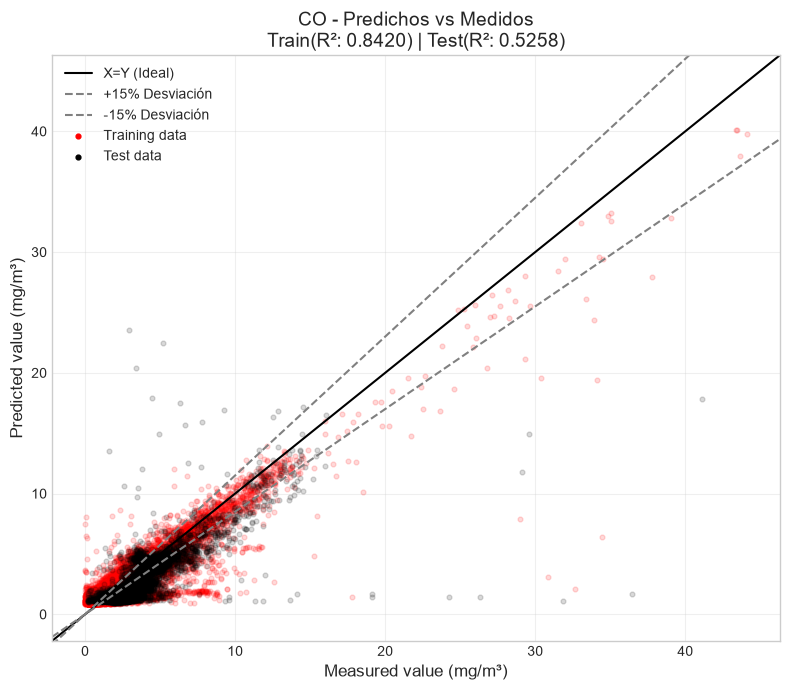


Generando gráfico: muestra del Train Set...


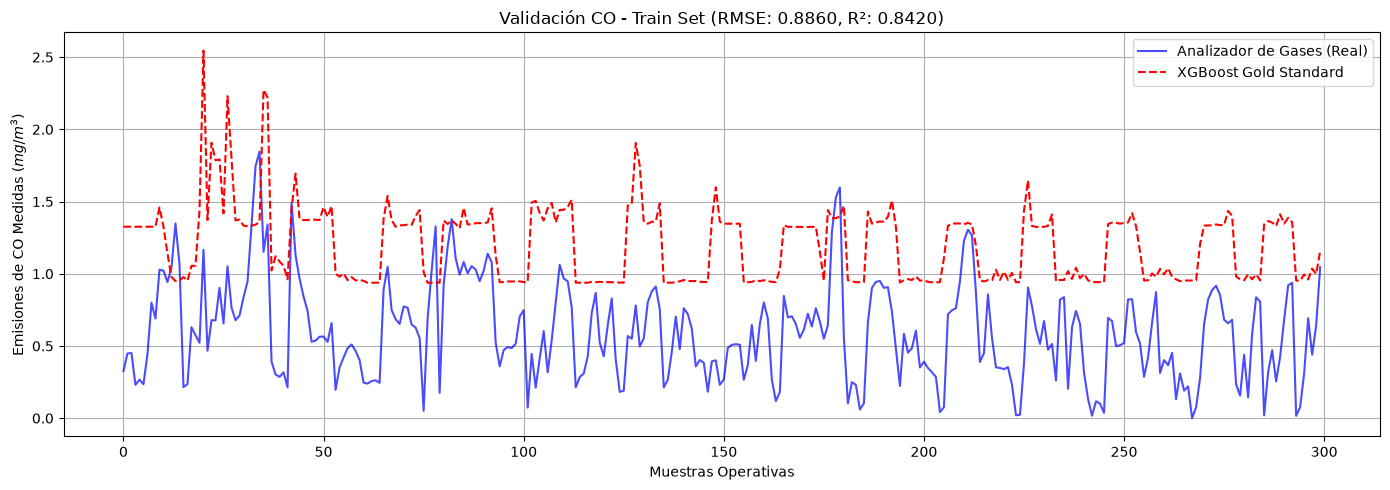


Generando gráfico: muestra del Test Set WF04 (WF04 — 2015)...


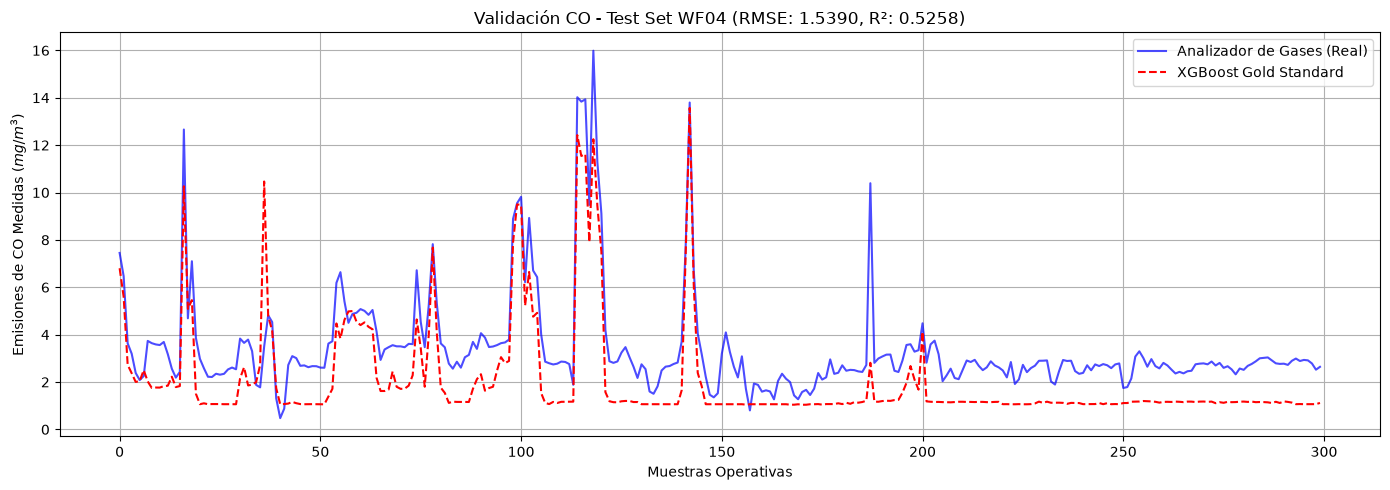

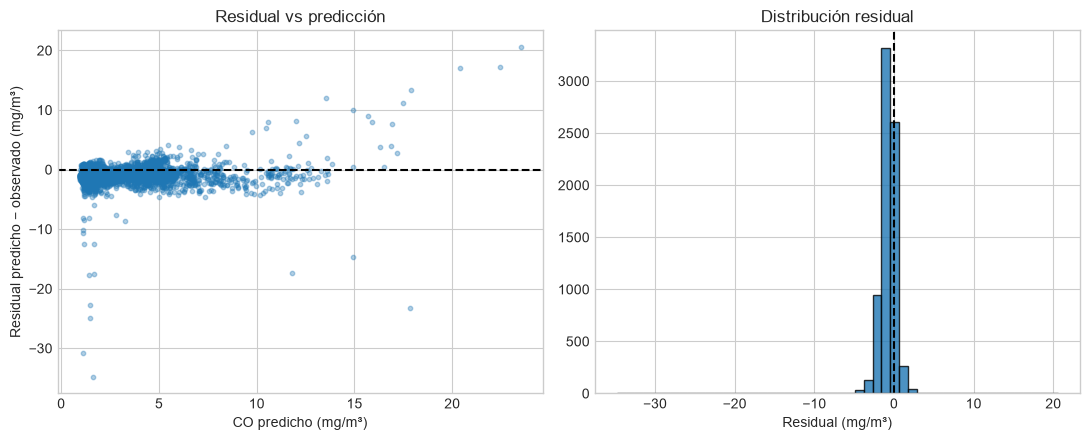

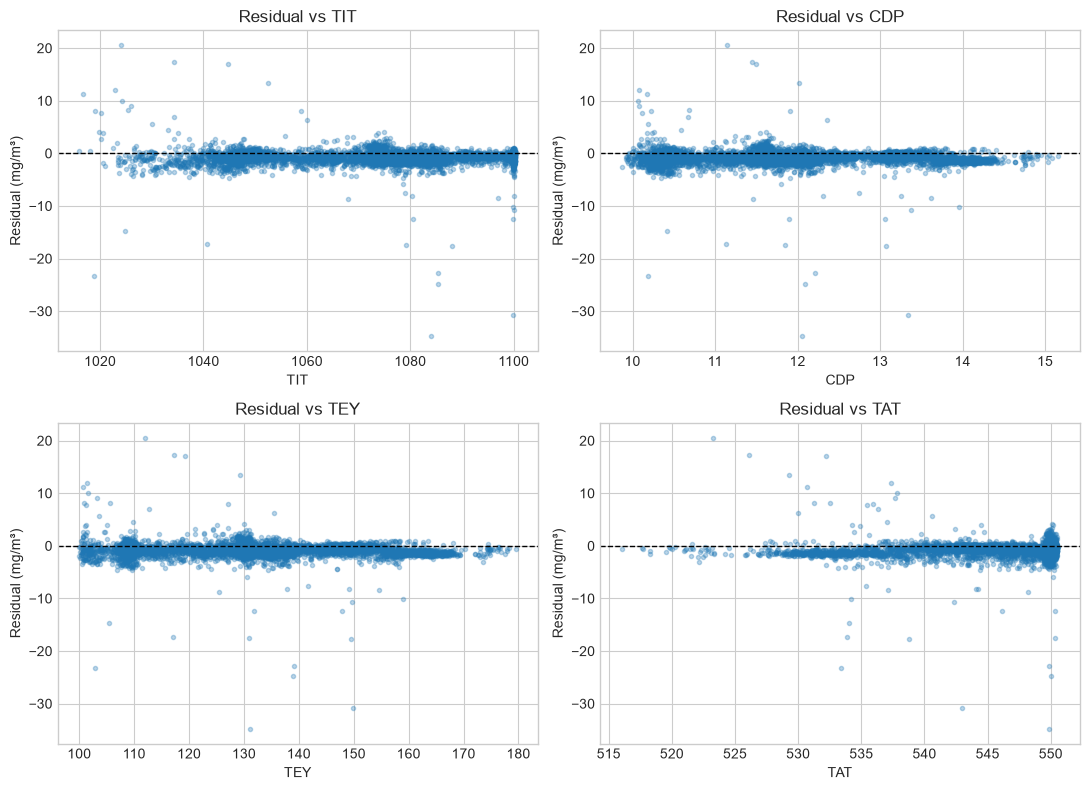

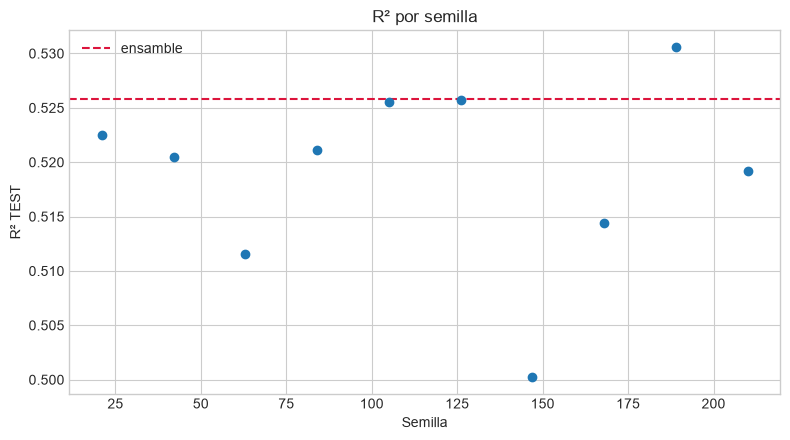

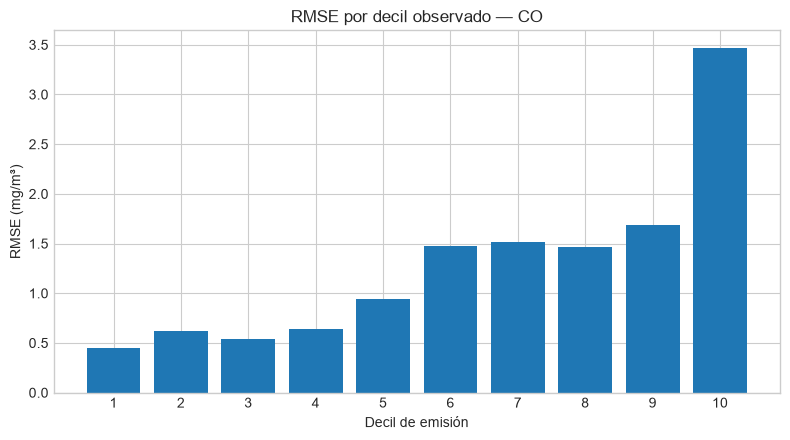

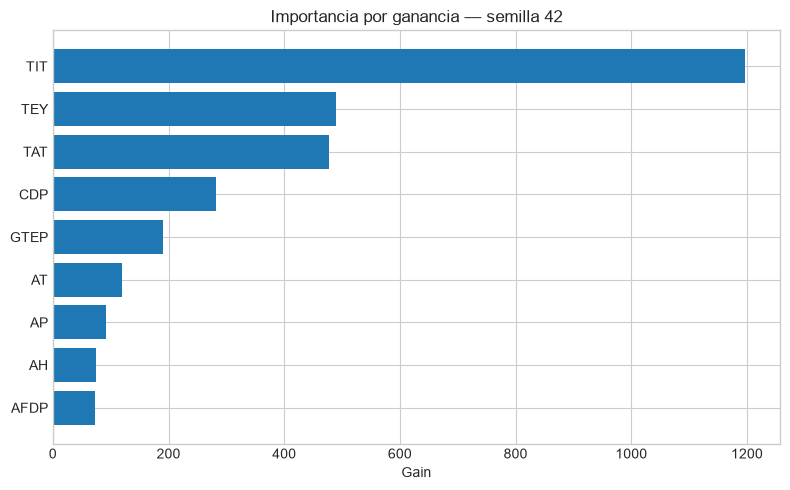

In [11]:
# [C-07.01] Figuras predictivas y de importancia
plt.style.use("seaborn-v0_8-whitegrid")


def save_figure(figure, path: Path) -> None:
    figure.tight_layout()
    figure.savefig(path, dpi=170, bbox_inches="tight")
    plt.show()


print(f"\nGenerando gráfico combinado de predichos vs. medidos para {TARGET}...")

# DEV se muestra como referencia descriptiva del ajuste final. No interviene
# en la evaluación TEST ni modifica modelos, árboles, semillas o configuración.
y_dev = DEV_DATA[TARGET].to_numpy(float)
dev_prediction_matrix = []
for seed in FINAL_SEEDS:
    predicted_dev_model = FINAL_MODELS[seed].predict(x_dev)
    dev_prediction_matrix.append(
        target_inverse(predicted_dev_model, target_transform)
    )
dev_ensemble = np.mean(np.vstack(dev_prediction_matrix), axis=0)
dev_ensemble_metrics = predictive_metrics(y_dev, dev_ensemble)
observed = y_test
ensemble = ENSEMBLE_PREDICTION

minimum_value = min(
    float(y_dev.min()),
    float(observed.min()),
    float(dev_ensemble.min()),
    float(ensemble.min()),
)
maximum_value = max(
    float(y_dev.max()),
    float(observed.max()),
    float(dev_ensemble.max()),
    float(ensemble.max()),
)
margin = (maximum_value - minimum_value) * 0.05
limits = [minimum_value - margin, maximum_value + margin]
limits_array = np.asarray(limits)
target_label = "NOx" if TARGET == "NOX" else TARGET

figure, axis = plt.subplots(figsize=(8, 7))
axis.plot(
    limits,
    limits,
    color="black",
    label="X=Y (Ideal)",
    linestyle="-",
    linewidth=1.5,
)
axis.plot(
    limits_array,
    limits_array * 1.15,
    color="gray",
    label="+15% Desviación",
    linestyle="--",
)
axis.plot(
    limits_array,
    limits_array * 0.85,
    color="gray",
    label="-15% Desviación",
    linestyle="--",
)
axis.scatter(
    y_dev,
    dev_ensemble,
    color="red",
    label="Training data",
    s=12,
    alpha=0.15,
)
axis.scatter(
    observed,
    ensemble,
    color="black",
    label="Test data",
    s=12,
    alpha=0.15,
)
axis.set_ylabel("Predicted value (mg/m³)", fontsize=12)
axis.set_xlabel("Measured value (mg/m³)", fontsize=12)
axis.set_xlim(limits)
axis.set_ylim(limits)
axis.set_title(
    f"{target_label} - Predichos vs Medidos\n"
    f"Train(R²: {dev_ensemble_metrics['R2']:.4f}) | "
    f"Test(R²: {ENSEMBLE_METRICS['R2']:.4f})",
    fontsize=14,
)
legend = axis.legend(loc="upper left", fontsize=10)
for legend_handle in legend.legend_handles:
    legend_handle.set_alpha(1.0)
axis.grid(True, alpha=0.3)
save_figure(figure, PATHS.figures_test / "01_paridad_ensamble_test.png")

OPERATIONAL_SAMPLE_ROWS = 300


def plot_co_operational_sample(
    y_true: np.ndarray,
    predicted: np.ndarray,
    split_type: str,
    metrics: dict,
    output_path: Path,
) -> None:
    """Reproduce para CO los paneles operativos DEV y TEST del referente PINN."""
    sample_rows = min(OPERATIONAL_SAMPLE_ROWS, len(y_true), len(predicted))
    with plt.style.context("default"):
        figure, axis = plt.subplots(figsize=(14, 5))
        axis.plot(
            y_true[:sample_rows],
            label="Analizador de Gases (Real)",
            color="blue",
            alpha=0.7,
        )
        axis.plot(
            predicted[:sample_rows],
            label="XGBoost Gold Standard",
            color="red",
            linestyle="dashed",
        )
        axis.set_title(
            f"Validación CO - {split_type} "
            f"(RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f})"
        )
        axis.set_ylabel(r"Emisiones de CO Medidas ($mg/m^3$)")
        axis.set_xlabel("Muestras Operativas")
        axis.legend()
        axis.grid(True)
        save_figure(figure, output_path)


print("\nGenerando gráfico: muestra del Train Set...")
plot_co_operational_sample(
    y_dev,
    dev_ensemble,
    "Train Set",
    dev_ensemble_metrics,
    PATHS.figures_test / "02_serie_ensamble_DEV.png",
)

print("\nGenerando gráfico: muestra del Test Set WF04 (WF04 — 2015)...")
plot_co_operational_sample(
    observed,
    ensemble,
    "Test Set WF04",
    ENSEMBLE_METRICS,
    PATHS.figures_test / "02_serie_ensamble_test.png",
)

residual = ENSEMBLE_PREDICTION - y_test
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(ENSEMBLE_PREDICTION, residual, s=10, alpha=0.35)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set(
    title="Residual vs predicción",
    xlabel=f"{TARGET} predicho (mg/m³)",
    ylabel="Residual predicho − observado (mg/m³)",
)
axes[1].hist(residual, bins=50, edgecolor="black", alpha=0.8)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="Distribución residual", xlabel="Residual (mg/m³)")
save_figure(figure, PATHS.figures_test / "03_diagnostico_residuales_test.png")

key_features = ["AT", "TIT", "TEY", "CDP"] if TARGET == "NOX" else [
    "TIT", "CDP", "TEY", "TAT"
]
figure, axes = plt.subplots(2, 2, figsize=(11, 8))
for axis, feature in zip(axes.ravel(), key_features):
    axis.scatter(TEST_DATA[feature], residual, s=9, alpha=0.30)
    axis.axhline(0, color="black", linestyle="--", linewidth=1)
    axis.set(xlabel=feature, ylabel="Residual (mg/m³)", title=f"Residual vs {feature}")
save_figure(figure, PATHS.figures_test / "04_residuales_variables_operativas.png")

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.errorbar(
    TEST_METRICS_BY_SEED.seed,
    TEST_METRICS_BY_SEED.R2,
    fmt="o",
)
axis.axhline(ENSEMBLE_METRICS["R2"], color="crimson", linestyle="--", label="ensamble")
axis.set(title="R² por semilla", xlabel="Semilla", ylabel="R² TEST")
axis.legend()
save_figure(figure, PATHS.figures_summary / "05_r2_por_semilla.png")

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.bar(DECILE_METRICS.decile.astype(str), DECILE_METRICS.RMSE)
axis.set(
    title=f"RMSE por decil observado — {TARGET}",
    xlabel="Decil de emisión",
    ylabel="RMSE (mg/m³)",
)
save_figure(figure, PATHS.figures_summary / "06_rmse_por_decil.png")

representative_booster = FINAL_MODELS[REPRESENTATIVE_SEED].get_booster()
gain = representative_booster.get_score(importance_type="gain")
IMPORTANCE = pd.DataFrame(
    {
        "feature": FEATURES,
        "gain": [float(gain.get(feature, 0.0)) for feature in FEATURES],
    }
).sort_values("gain", ascending=True)
atomic_csv(PATHS.tables / "feature_importance_gain_seed42.csv", IMPORTANCE)
figure, axis = plt.subplots(figsize=(8, 5))
axis.barh(IMPORTANCE.feature, IMPORTANCE.gain)
axis.set(title="Importancia por ganancia — semilla 42", xlabel="Gain")
save_figure(figure, PATHS.figures_summary / "07_importancia_gain_seed42.png")

## SEC-08 — Complejidad, almacenamiento y latencia CPU

### C-08.01 / TAB-02 / CHK-08 — Huella normalizada

Se separan árboles/nodos/hojas, UBJ desplegable, JSON diagnóstico, tamaño
total del ensamble y latencia. Un nodo no se denomina “parámetro”.


In [12]:
# [C-08.01] Complejidad estructural y benchmark CPU
def tree_depth(node: dict) -> int:
    children = node.get("children", [])
    if not children:
        return 0
    return 1 + max(tree_depth(child) for child in children)


def latency_distribution(operation, warmup: int, repetitions: int) -> dict:
    for _ in range(warmup):
        operation()
    timings = []
    for _ in range(repetitions):
        started = time.perf_counter()
        operation()
        timings.append((time.perf_counter() - started) * 1000)
    return {
        "median_ms": float(np.median(timings)),
        "p95_ms": float(np.quantile(timings, 0.95)),
        "p99_ms": float(np.quantile(timings, 0.99)),
    }


representative_path = (
    PATHS.models / f"XGBOOST_{TARGET}_WF_seed{REPRESENTATIVE_SEED}.ubj"
)
cpu_booster = xgb.Booster()
cpu_booster.load_model(representative_path)
cpu_booster.set_param({"device": "cpu", "nthread": 1})
tree_frame = cpu_booster.trees_to_dataframe()
dumps = [json.loads(item) for item in cpu_booster.get_dump(dump_format="json")]
effective_depths = [tree_depth(tree) for tree in dumps]

with tempfile.NamedTemporaryFile(suffix=".json", delete=False) as handle:
    json_path = Path(handle.name)
try:
    cpu_booster.save_model(json_path)
    json_bytes = json_path.stat().st_size
finally:
    json_path.unlink(missing_ok=True)

x_one = TEST_DATA[FEATURES].iloc[:1].to_numpy(np.float32)
x_batch = TEST_DATA[FEATURES].to_numpy(np.float32)

def engine_operation() -> None:
    cpu_booster.inplace_predict(x_one, validate_features=False)


def end_to_end_operation() -> None:
    if not np.isfinite(x_one).all():
        raise ValueError("Entrada no finita")
    predicted_model = cpu_booster.inplace_predict(
        x_one,
        validate_features=False,
    )
    target_inverse(predicted_model, target_transform)


engine_latency = latency_distribution(
    engine_operation,
    LATENCY_WARMUP,
    LATENCY_REPETITIONS,
)
end_to_end_latency = latency_distribution(
    end_to_end_operation,
    LATENCY_WARMUP,
    LATENCY_REPETITIONS,
)

def batch_operation() -> None:
    cpu_booster.inplace_predict(x_batch, validate_features=False)


batch_latency = latency_distribution(
    batch_operation,
    THROUGHPUT_WARMUP,
    THROUGHPUT_REPETITIONS,
)
throughput = float(
    len(x_batch) / (batch_latency["median_ms"] / 1000)
)
ensemble_bytes = int(sum(path.stat().st_size for path in model_files))
FOOTPRINT = {
    "measurement_scope": "representative_seed_model_and_full_ensemble_storage",
    "representative_seed": REPRESENTATIVE_SEED,
    "tree_count": int(tree_frame.Tree.nunique()),
    "node_count": int(len(tree_frame)),
    "leaf_count": int(tree_frame.Feature.eq("Leaf").sum()),
    "effective_depth_max": int(max(effective_depths)),
    "effective_depth_median": float(np.median(effective_depths)),
    "configured_max_depth": int(BEST_CONFIG["xgb_parameters"]["max_depth"]),
    "serialized_ubj_mib": float(representative_path.stat().st_size / 2**20),
    "serialized_json_mib": float(json_bytes / 2**20),
    "ensemble_ubj_mib": float(ensemble_bytes / 2**20),
    "ensemble_model_count": len(FINAL_SEEDS),
    "model_storage_format": "UBJ",
    "cpu_model": platform.processor() or platform.machine(),
    "cpu_platform": platform.platform(),
    "cpu_physical_cores": psutil.cpu_count(logical=False),
    "cpu_logical_threads": psutil.cpu_count(logical=True),
    "benchmark_device": "cpu",
    "benchmark_threads": 1,
    "latency_batch_size": 1,
    "latency_warmup": LATENCY_WARMUP,
    "latency_repetitions": LATENCY_REPETITIONS,
    "throughput_warmup": THROUGHPUT_WARMUP,
    "throughput_repetitions": THROUGHPUT_REPETITIONS,
    "engine_latency_definition": "preprocessed_X_to_model_output",
    "end_to_end_latency_definition": "finite_check_model_inverse_target",
    "engine_latency_cpu_median_ms": engine_latency["median_ms"],
    "engine_latency_cpu_p95_ms": engine_latency["p95_ms"],
    "engine_latency_cpu_p99_ms": engine_latency["p99_ms"],
    "end_to_end_latency_cpu_median_ms": end_to_end_latency["median_ms"],
    "end_to_end_latency_cpu_p95_ms": end_to_end_latency["p95_ms"],
    "end_to_end_latency_cpu_p99_ms": end_to_end_latency["p99_ms"],
    "throughput_batch_rows": len(x_batch),
    "throughput_cpu_samples_per_s": throughput,
    "throughput_batch_median_ms": batch_latency["median_ms"],
    "storage_note": "UBJ and JSON are serialization sizes, not RAM",
}
FOOTPRINT_TABLE = pd.DataFrame([FOOTPRINT])
atomic_csv(PATHS.tables / "model_complexity.csv", FOOTPRINT_TABLE)
atomic_csv(PATHS.tables / "computational_footprint.csv", FOOTPRINT_TABLE)
atomic_json(PATHS.tables / "computational_footprint.json", FOOTPRINT)

separator = "=" * 68
target_label = "NOx" if TARGET == "NOX" else TARGET
print(separator)
print(f"HUELLA COMPUTACIONAL - XGBOOST {target_label} WALK-FORWARD")
print(separator)
print("Complejidad estructural")
print(f"Árboles                      : {FOOTPRINT['tree_count']:,}")
print(f"Nodos totales                : {FOOTPRINT['node_count']:,}")
print(f"Hojas totales                : {FOOTPRINT['leaf_count']:,}")
print(
    "Profundidad máxima efectiva: "
    f"{FOOTPRINT['effective_depth_max']}"
)
print(
    "Profundidad mediana efectiva: "
    f"{FOOTPRINT['effective_depth_median']:.1f}"
)
print(
    "Profundidad máxima configurada: "
    f"{FOOTPRINT['configured_max_depth']}"
)
print("Almacenamiento serializado (no equivale a RAM)")
print(
    "Modelo UBJ representativo  : "
    f"{FOOTPRINT['serialized_ubj_mib']:.6f} MiB"
)
print(
    "Modelo JSON diagnóstico    : "
    f"{FOOTPRINT['serialized_json_mib']:.6f} MiB"
)
print(
    "Ensamble UBJ (10 modelos)  : "
    f"{FOOTPRINT['ensemble_ubj_mib']:.6f} MiB"
)
print("Inferencia CPU - batch = 1")
print(f"Hilos del benchmark          : {FOOTPRINT['benchmark_threads']}")
print(f"Warm-up                      : {FOOTPRINT['latency_warmup']}")
print(f"Repeticiones                 : {FOOTPRINT['latency_repetitions']}")
print(
    "Latencia motor mediana     : "
    f"{FOOTPRINT['engine_latency_cpu_median_ms']:.6f} ms"
)
print(
    "Latencia motor p95         : "
    f"{FOOTPRINT['engine_latency_cpu_p95_ms']:.6f} ms"
)
print(
    "Latencia motor p99         : "
    f"{FOOTPRINT['engine_latency_cpu_p99_ms']:.6f} ms"
)
print(
    "Latencia end-to-end mediana: "
    f"{FOOTPRINT['end_to_end_latency_cpu_median_ms']:.6f} ms"
)
print(
    "Latencia end-to-end p95    : "
    f"{FOOTPRINT['end_to_end_latency_cpu_p95_ms']:.6f} ms"
)
print(
    "Latencia end-to-end p99    : "
    f"{FOOTPRINT['end_to_end_latency_cpu_p99_ms']:.6f} ms"
)
print("Procesamiento por lotes")
print(f"Filas por lote               : {FOOTPRINT['throughput_batch_rows']:,}")
print(f"Warm-up de lotes             : {FOOTPRINT['throughput_warmup']}")
print(f"Repeticiones de lotes        : {FOOTPRINT['throughput_repetitions']}")
print(
    "Latencia mediana del lote  : "
    f"{FOOTPRINT['throughput_batch_median_ms']:.6f} ms"
)
print(
    "Throughput CPU             : "
    f"{FOOTPRINT['throughput_cpu_samples_per_s']:.3f} muestras/s"
)
print(separator)
display(FOOTPRINT_TABLE.T.rename(columns={0: "valor"}))

HUELLA COMPUTACIONAL - XGBOOST CO WALK-FORWARD
Complejidad estructural
Árboles                      : 144
Nodos totales                : 11,142
Hojas totales                : 5,643
Profundidad máxima efectiva: 7
Profundidad mediana efectiva: 7.0
Profundidad máxima configurada: 7
Almacenamiento serializado (no equivale a RAM)
Modelo UBJ representativo  : 0.453125 MiB
Modelo JSON diagnóstico    : 0.607572 MiB
Ensamble UBJ (10 modelos)  : 4.545921 MiB
Inferencia CPU - batch = 1
Hilos del benchmark          : 1
Warm-up                      : 50
Repeticiones                 : 200
Latencia motor mediana     : 0.076150 ms
Latencia motor p95         : 0.217600 ms
Latencia motor p99         : 0.273876 ms
Latencia end-to-end mediana: 0.076800 ms
Latencia end-to-end p95    : 0.186035 ms
Latencia end-to-end p99    : 0.276784 ms
Procesamiento por lotes
Filas por lote               : 7,384
Warm-up de lotes             : 10
Repeticiones de lotes        : 30
Latencia mediana del lote  : 13.455800 ms
T

,valor
measurement_scope,representative_seed_model_and_full_ensemble_st...
representative_seed,42
tree_count,144
node_count,11142
leaf_count,5643
effective_depth_max,7
effective_depth_median,7.0
configured_max_depth,7
serialized_ubj_mib,0.453125
serialized_json_mib,0.607572


## SEC-09 — Persistencia, manifiesto y cierre

### C-09.01 / ART-04 — Copia trazable e informe técnico

Se preservan hashes de las entradas OPT y se documentan alcance y
limitaciones antes de cerrar la evaluación.


In [13]:
# [C-09.01] Copia FROZEN e informe
source_config = FROZEN["paths"]["best_config"]
source_policy = FROZEN["paths"]["policy"]
copied_config = PATHS.configs / source_config.name
copied_policy = PATHS.configs / source_policy.name
shutil.copy2(source_config, copied_config)
shutil.copy2(source_policy, copied_policy)
if sha256_file(source_config) != sha256_file(copied_config):
    raise RuntimeError("La copia de BEST_CONFIG alteró el hash")
if sha256_file(source_policy) != sha256_file(copied_policy):
    raise RuntimeError("La copia de la política alteró el hash")

input_snapshot = {
    "status": "VERIFIED",
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "protocol_version": PROTOCOL_VERSION,
    "opt_version": OPT_VERSION,
    "protocol_notebook": PROTOCOL_NOTEBOOK_NAME,
    "opt_notebook": OPT_NOTEBOOK_NAME,
    "config_hash": BEST_CONFIG["config_hash"],
    "row_assignment_sha256": FROZEN["assignment_hash"],
    "fold_summary_sha256": FROZEN["fold_hash"],
    "best_config_file_sha256": sha256_file(source_config),
    "training_policy_file_sha256": sha256_file(source_policy),
    "pre_test_gate_sha256": PRE_TEST_GATE["gate_file_sha256"],
}
atomic_json(PATHS.configs / "FROZEN_INPUT_SNAPSHOT_R1F_STD.json", input_snapshot)

report = f"""# Informe técnico — XGBoost {TARGET} walk-forward FINAL R1F_STD

## Diseño

Se consumió sin cambios la configuración {BEST_CONFIG['config_hash']} y la
política de {FINAL_N_ESTIMATORS} árboles. Se entrenaron diez modelos con DEV
2011–2014 antes de abrir 2015. El ensamble es la media aritmética de las diez
semillas predeclaradas. No se aplicaron restricciones monotónicas, pérdida
física, sintéticos, selección de variables, escalamiento de X ni clipping.

## Resultado WF04 — TEST 2015

- R² del ensamble: {ENSEMBLE_METRICS['R2']:.6f}.
- RMSE: {ENSEMBLE_METRICS['RMSE']:.6f} mg/m³.
- MAE: {ENSEMBLE_METRICS['MAE']:.6f} mg/m³.
- Sesgo: {ENSEMBLE_METRICS['bias']:.6f} mg/m³.
- RMSE del decil superior: {ENSEMBLE_METRICS['tail_RMSE']:.6f} mg/m³.
- Predicciones negativas: {ENSEMBLE_METRICS['negative_prediction_pct']:.6f} %.

## Complejidad

- Árboles: {FOOTPRINT['tree_count']}.
- Nodos: {FOOTPRINT['node_count']}.
- Hojas: {FOOTPRINT['leaf_count']}.
- UBJ representativo: {FOOTPRINT['serialized_ubj_mib']:.6f} MiB.
- UBJ de diez modelos: {FOOTPRINT['ensemble_ubj_mib']:.6f} MiB.
- Latencia CPU motor, batch=1: mediana=
  {FOOTPRINT['engine_latency_cpu_median_ms']:.6f} ms,
  p95={FOOTPRINT['engine_latency_cpu_p95_ms']:.6f} ms y
  p99={FOOTPRINT['engine_latency_cpu_p99_ms']:.6f} ms.
- Latencia CPU end-to-end, batch=1: mediana=
  {FOOTPRINT['end_to_end_latency_cpu_median_ms']:.6f} ms,
  p95={FOOTPRINT['end_to_end_latency_cpu_p95_ms']:.6f} ms y
  p99={FOOTPRINT['end_to_end_latency_cpu_p99_ms']:.6f} ms.
- Throughput CPU sobre {FOOTPRINT['throughput_batch_rows']} filas:
  {FOOTPRINT['throughput_cpu_samples_per_s']:.3f} muestras/s.

## Alcance

Los resultados describen la frontera prospectiva 2011–2014 → 2015. No
demuestran desempeño fuera del periodo observado, causalidad ni conformidad
regulatoria PEMS/CEMS/RATA.
"""
atomic_text(
    PATHS.reports / "INFORME_TECNICO_XGBOOST_CO_WF_FINAL_R1F_STD.md",
    report,
)

### C-09.02 / ART-05 / CHK-09 — Manifiesto final y hashes

El cierre exige diez modelos, apertura única de TEST, tablas, figuras y
huella computacional. Los artefactos quedan inventariados con SHA-256.


In [14]:
# [C-09.02] Manifiesto final e inventario
required_files = [
    PATHS.audit / "ENVIRONMENT_XGBOOST_CO_WF_FINAL_R1F_STD.json",
    PATHS.audit / "FROZEN_INPUT_AUDIT_XGBOOST_CO_WF_R1F.csv",
    PATHS.audit / "TARGET_ACCESS_AUDIT_PRE_TEST_R1F_STD.json",
    PATHS.audit / "PRE_TEST_GATE_R1F_STD.json",
    PATHS.audit / "TEST_ACCESS_AUDIT_R1F_STD.json",
    PATHS.audit / "MODEL_RELOAD_AUDIT_XGBOOST_CO_WF_R1F_STD.csv",
    copied_config,
    copied_policy,
    PATHS.configs / "FROZEN_INPUT_SNAPSHOT_R1F_STD.json",
    PATHS.tables / "training_summary_by_seed.csv",
    PATHS.tables / "test_predictions.csv",
    PATHS.tables / "test_metrics_by_seed.csv",
    PATHS.tables / "test_metrics_ensemble.json",
    PATHS.tables / "test_summary_multiseed.csv",
    PATHS.tables / "test_metrics_by_decile.csv",
    PATHS.tables / "feature_importance_gain_seed42.csv",
    PATHS.tables / "model_complexity.csv",
    PATHS.tables / "computational_footprint.csv",
    PATHS.tables / "computational_footprint.json",
    PATHS.reports / "INFORME_TECNICO_XGBOOST_CO_WF_FINAL_R1F_STD.md",
]
required_files.extend(model_files)
required_files.extend(metadata_files)
required_figure_files = [
    PATHS.figures_test / "01_paridad_ensamble_test.png",
    PATHS.figures_test / "02_serie_ensamble_DEV.png",
    PATHS.figures_test / "02_serie_ensamble_test.png",
    PATHS.figures_test / "03_diagnostico_residuales_test.png",
    PATHS.figures_test / "04_residuales_variables_operativas.png",
    PATHS.figures_summary / "05_r2_por_semilla.png",
    PATHS.figures_summary / "06_rmse_por_decil.png",
    PATHS.figures_summary / "07_importancia_gain_seed42.png",
]
required_files.extend(required_figure_files)
missing = [str(path) for path in required_files if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Artefactos finales ausentes: {missing}")
if TEST_ACCESS_COUNT != 1 or not TEST_ACCESS_AUDIT["opened_once"]:
    raise RuntimeError("Contrato de apertura única de TEST violado")
if model_hashes_before_test != {
    path.name: sha256_file(path) for path in model_files
}:
    raise RuntimeError("Un modelo cambió después de abrir TEST")
if metadata_hashes_before_test != {
    path.name: sha256_file(path) for path in metadata_files
}:
    raise RuntimeError("Un sidecar cambió después de abrir TEST")

ARTIFACT_HASHES = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(PATHS.work)).replace("\\", "/"),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in sorted(set(required_files))
    ]
)
atomic_csv(
    PATHS.audit / "HASHES_XGBOOST_CO_WF_FINAL_R1F_STD.csv",
    ARTIFACT_HASHES,
)
FINAL_MANIFEST = {
    "status": "COMPLETE",
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "scope": "WF04 prospective annual holdout: 2011-2014 to 2015",
    "producer_notebook": CURRENT_NOTEBOOK_NAME,
    "upstream_notebooks": [PROTOCOL_NOTEBOOK_NAME, OPT_NOTEBOOK_NAME],
    "protocol_version": PROTOCOL_VERSION,
    "opt_version": OPT_VERSION,
    "config_hash": BEST_CONFIG["config_hash"],
    "target": TARGET,
    "features": FEATURES,
    "target_transform": target_transform,
    "pure_data_driven_contract": BEST_CONFIG[
        "pure_data_driven_contract"
    ],
    "final_n_estimators": FINAL_N_ESTIMATORS,
    "final_seeds": FINAL_SEEDS,
    "ensemble_rule": ENSEMBLE_RULE,
    "models_frozen_before_test": True,
    "test_opened_once": True,
    "test_access_count": TEST_ACCESS_COUNT,
    "test_content_sha256_computed_after_gate": True,
    "dev_rows": len(DEV_DATA),
    "test_rows": len(TEST_DATA),
    "training_elapsed_seconds": FINAL_TRAINING_SECONDS,
    "ensemble_metrics": ENSEMBLE_METRICS,
    "computational_footprint": FOOTPRINT,
    "artifact_count": len(ARTIFACT_HASHES),
    "artifacts": ARTIFACT_HASHES.to_dict(orient="records"),
    "limitations": [
        "No demuestra generalización más allá de la frontera anual 2015.",
        "No demuestra desempeño fuera del periodo observado.",
        "No equivale a certificación PEMS, RATA ni homologación regulatoria.",
    ],
}
atomic_json(
    PATHS.work / "MANIFEST_XGBOOST_CO_WF_FINAL_R1F_STD.json",
    FINAL_MANIFEST,
)
print(
    {
        "estado": FINAL_MANIFEST["status"],
        "CHK-09": "PASS",
        "modelos": len(FINAL_SEEDS),
        "artefactos": len(ARTIFACT_HASHES),
        "TEST_abierto_una_vez": True,
        "salida": str(PATHS.work),
    }
)

{'estado': 'COMPLETE', 'CHK-09': 'PASS', 'modelos': 10, 'artefactos': 48, 'TEST_abierto_una_vez': True, 'salida': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\wf\\work_xgboost_co_wf_final_r1f_std'}

## OUT-01 — Resumen ejecutivo

El notebook ejecuta una evaluación prospectiva única `WF04`: entrena con
2011–2014, congela diez modelos, abre 2015 una sola vez y persiste evidencia
auditable. No reabre decisiones de OPT.